# Smart Personal Finance Intelligence Dashboard

## Project Objective

Analyze personal financial transactions from Bank and UPI sources to identify:

- Income vs Expense Trends
- Savings Performance
- Spending Intelligence
- Financial Behavior Patterns
- Payment Channel Analytics

Tools Used:
- Python
- Pandas
- NumPy
- Power BI

In [201]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [202]:
bank_df = pd.read_excel(r"C:\Users\91888\Downloads\need\powerbi\new_project\Dataset\bank_statement (1).xlsx")
upi_df = pd.read_excel(r"C:\Users\91888\Downloads\need\powerbi\new_project\Dataset\upi_transactions (1).xlsx")

In [203]:
print("Bank Shape :", bank_df.shape)

print("UPI Shape :", upi_df.shape)

bank_df.head()

Bank Shape : (156, 6)
UPI Shape : (679, 6)


,Date,Description,Amount,Type,Source,Category
0,2023-06-05 00:00:00,NEFT/HOSTEL FEES/Hostel rent,-3100,debit,Bank,Rent
1,2023-12-02 00:00:00,NEFT/FATHER A/C/Pocket money REF909,9900,Credit,Bank,monthly pocket money
2,2025-05-30 00:00:00,AUTOPAY/JIO/Mobile recharge,-350,Debit,Bank,Utilities
3,2024-08-10 00:00:00,NEFT/ONLINE COURSE/Course fee,-2900,Debit,Bank,EDUCATION
4,23-10-2023,AUTOPAY/JIO/MOBILE RECHARGE - SETTLED,-400,debit,Bank,utility


# Data Cleaning

In [205]:
bank_df.columns = (
    bank_df.columns
    .str.strip()
    .str.replace(" ","_")
)

upi_df.columns = (
    upi_df.columns
    .str.strip()
    .str.replace(" ","_")
)

# Date Conversion

In [207]:
bank_df["Date"] = pd.to_datetime(
    bank_df["Date"],
    errors="coerce"
)

upi_df["Date"] = (
    upi_df["Date"]
      .astype(str)
      .str.strip()
)

upi_df["Date"] = pd.to_datetime(
    upi_df["Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

# Missing Data Check

In [209]:
print(bank_df["Date"].isnull().sum())
print(upi_df["Date"].isnull().sum())

0
0


# Drop Invalid Dates

In [211]:
bank_df = bank_df.dropna(subset=["Date"])
upi_df = upi_df.dropna(subset=["Date"])

# Feature Engineering

In [213]:
bank_df["Source"] = "Bank"

upi_df["Source"] = "UPI"

bank_df["Transaction_ID"] = (
    "BANK_" +
    (bank_df.index + 1).astype(str)
)

upi_df["Transaction_ID"] = (
    "UPI_" +
    (upi_df.index + 1).astype(str)
)

bank_df["Amount_Abs"] = (
    bank_df["Amount"].abs()
)

upi_df["Amount_Abs"] = (
    upi_df["Amount"].abs()
)

bank_df["Income_Expense"] = np.where(
    bank_df["Amount"] > 0,
    "Income",
    "Expense"
)

upi_df["Income_Expense"] = np.where(
    upi_df["Amount"] > 0,
    "Income",
    "Expense"
)

In [214]:
bank_df["Merchant"] = (
    bank_df["Description"]
      .fillna("Unknown")
)

upi_df["Merchant"] = (
    upi_df["Description"]
      .fillna("Unknown")
)

In [215]:
df = pd.concat(
    [bank_df, upi_df],
    ignore_index=True
)

df.drop_duplicates(inplace=True)

In [216]:
df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month_name()

df["Month_Year"] = (
    df["Date"]
      .dt.strftime("%b-%Y")
)

df["Day_Name"] = (
    df["Date"]
      .dt.day_name()
)

df["Week_Number"] = (
    df["Date"]
      .dt.isocalendar()
      .week
)

In [217]:
def clean_merchant(x):

    x = str(x).upper()

    if "SWIGGY" in x:
        return "Swiggy"

    elif "ZOMATO" in x:
        return "Zomato"

    elif "IRCTC" in x:
        return "IRCTC"

    elif "UBER" in x:
        return "Uber"

    elif "OLA" in x:
        return "Ola"

    elif "RAPIDO" in x:
        return "Rapido"

    elif "NETFLIX" in x:
        return "Netflix"

    elif "HOSTEL" in x:
        return "Hostel Rent"

    elif "LAPTOP" in x:
        return "Laptop Repair"

    elif "COURSE" in x:
        return "Online Course"

    else:
        return x.title()

In [218]:
df["Merchant"] = df["Merchant"].apply(clean_merchant)

In [219]:
def category_group(x):

    if x in ["Food","Shopping","Entertainment"]:
        return "Lifestyle"

    elif x in ["Rent","Utilities","Healthcare"]:
        return "Essentials"

    elif x == "Travel":
        return "Travel"

    elif x == "Salary":
        return "Income"

    else:
        return "Others"

In [220]:
df["Category"] = df["Merchant"].apply(category)

df["Category_Group"] = (
    df["Category"]
      .apply(category_group)
)

In [221]:
df["Day_Type"] = np.where(
    df["Date"].dt.dayofweek >= 5,
    "Weekend",
    "Weekday"
)

In [222]:
df["Quarter"] = (
    "Q" +
    df["Date"].dt.quarter.astype(str)
)

In [223]:
merchant_freq = (
    df.groupby("Merchant")
      .size()
      .reset_index(
          name="Merchant_Frequency"
      )
)

df = df.merge(
    merchant_freq,
    on="Merchant",
    how="left"
)

In [224]:
month_order = {
    "January":1,
    "February":2,
    "March":3,
    "April":4,
    "May":5,
    "June":6,
    "July":7,
    "August":8,
    "September":9,
    "October":10,
    "November":11,
    "December":12
}

df["Month_Number"] = (
    df["Month"]
      .map(month_order)
)

In [225]:
df["Transaction_Size"] = pd.cut(
    df["Amount_Abs"],
    bins=[0,500,2000,5000,100000],
    labels=[
        "Small",
        "Medium",
        "Large",
        "Very Large"
    ]
)

In [226]:
df["Net_Amount"] = np.where(
    df["Income_Expense"]=="Income",
    df["Amount_Abs"],
    -df["Amount_Abs"]
)

df = df.sort_values("Date")

df["Running_Balance"] = (
    df["Net_Amount"]
      .cumsum()
)

In [227]:
print(df["Source"].value_counts())

print(
    df.groupby("Category")
      ["Amount_Abs"]
      .sum()
      .sort_values(ascending=False)
)

df["Merchant"].value_counts().head(20)

Source
UPI     679
Bank    156
Name: count, dtype: int64
Category
Others           459080
Rent             104350
Travel            47975
Food              44041
Utilities         23300
Entertainment     20321
Shopping          16550
Healthcare         5850
Name: Amount_Abs, dtype: int64


Merchant
Zomato                                          50
IRCTC                                           49
Uber                                            48
Rapido                                          47
Swiggy                                          34
Hostel Rent                                     32
Ola                                             29
Netflix                                         16
Upi/Dominos/Food Order                          12
Upi/Chaipoint/Snacks - Settled                  11
Upi/Campus Canteen/Food                         10
Upi/Chaipoint/Snacks                             9
Upi/Friend Transfer/Personal                     9
Upi/Pvr Cinemas/Movie                            7
Autopay/Electricity Board/Electricity Bill       7
Upi/Myntra/Shopping - Settled                    7
Unknown                                          6
Upi/Cafe Mocha/Hangout                           6
Online Course                                    6
Upi/Dominos/Food Order

In [228]:
df.to_excel(
    "finance_dashboard_dataset.xlsx",
    index=False
)

# EDA

In [230]:
df.shape

df.columns

Index(['Date', 'Description', 'Amount', 'Type', 'Source', 'Category',
       'Transaction_ID', 'Amount_Abs', 'Income_Expense', 'Merchant', 'Year',
       'Month', 'Month_Year', 'Day_Name', 'Week_Number', 'Category_Group',
       'Day_Type', 'Quarter', 'Merchant_Frequency', 'Month_Number',
       'Transaction_Size', 'Net_Amount', 'Running_Balance'],
      dtype='object')

# Income vs Expense Count

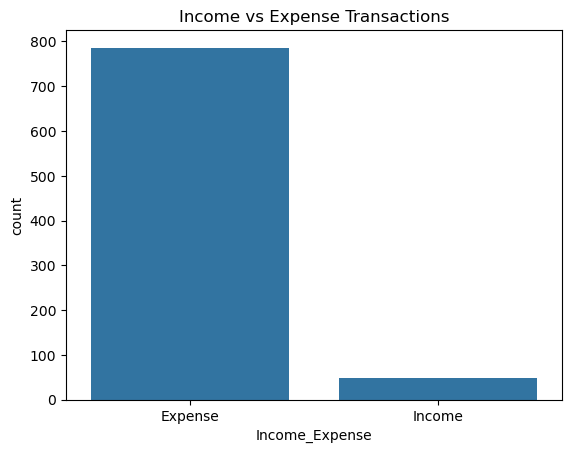

In [232]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(
    x="Income_Expense",
    data=df
)

plt.title("Income vs Expense Transactions")
plt.show()

# Income vs Expense Amount

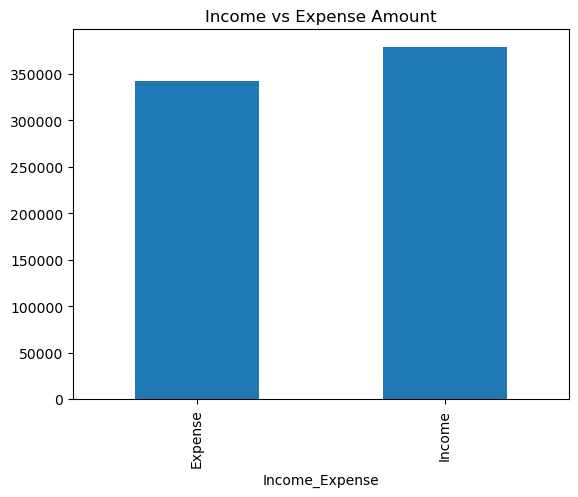

In [234]:
income_expense = (
    df.groupby("Income_Expense")
      ["Amount_Abs"]
      .sum()
)

income_expense.plot(
    kind="bar"
)

plt.title("Income vs Expense Amount")
plt.show()

# Top Spending Categories

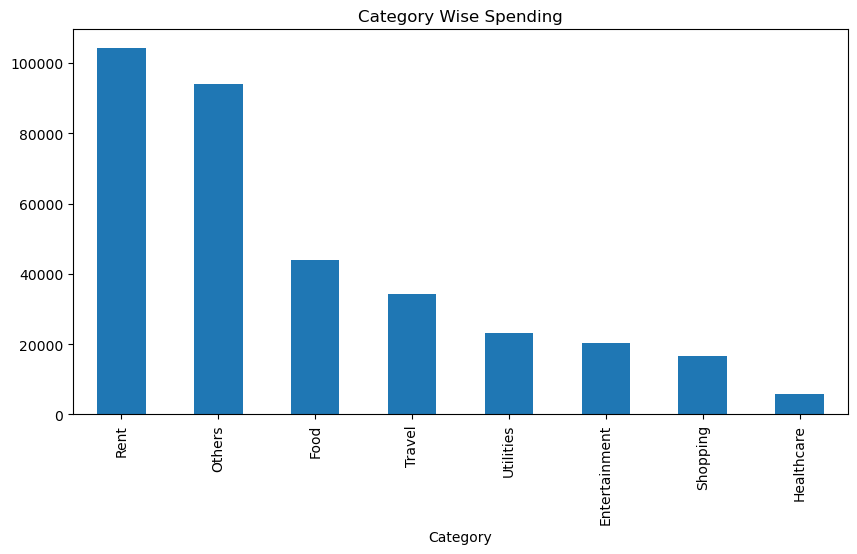

In [236]:
expense_df = df[
    df["Income_Expense"]=="Expense"
]

top_category = (
    expense_df.groupby("Category")
              ["Amount_Abs"]
              .sum()
              .sort_values(
                  ascending=False
              )
)

top_category.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Category Wise Spending")
plt.show()

# Top 10 Merchants

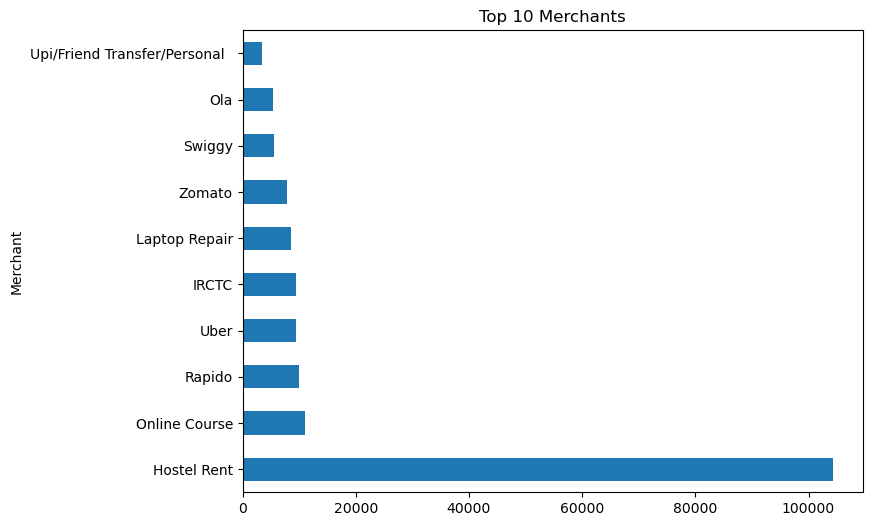

In [238]:
top_merchants = (
    expense_df.groupby("Merchant")
              ["Amount_Abs"]
              .sum()
              .sort_values(
                  ascending=False
              )
              .head(10)
)

top_merchants.plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Top 10 Merchants")
plt.show()

# Source Distribution

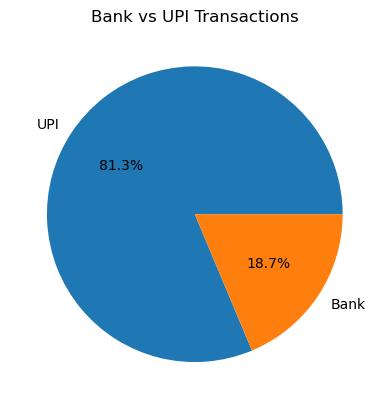

In [240]:
df["Source"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Bank vs UPI Transactions")
plt.ylabel("")
plt.show()

# Category Distribution

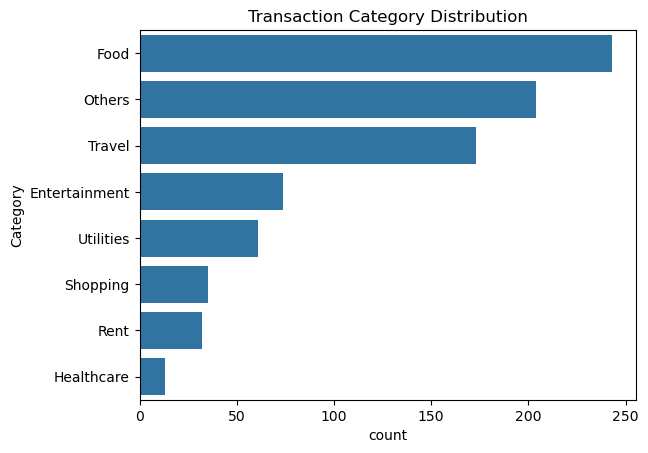

In [242]:
sns.countplot(
    y="Category",
    data=df,
    order=df["Category"]
            .value_counts()
            .index
)

plt.title("Transaction Category Distribution")
plt.show()

# Monthly Transaction Count

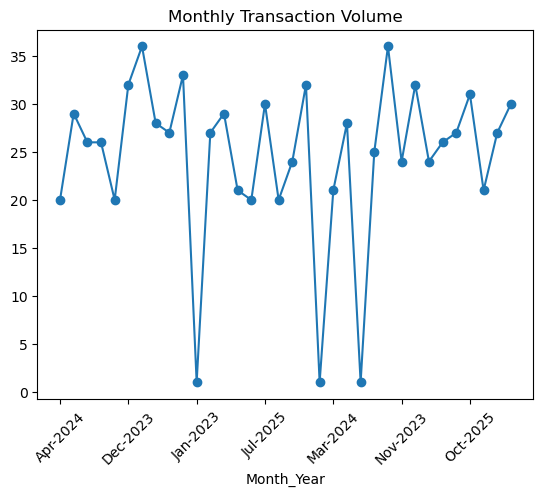

In [244]:
monthly_txn = (
    df.groupby("Month_Year")
      ["Transaction_ID"]
      .count()
)

monthly_txn.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Transaction Volume")
plt.xticks(rotation=45)
plt.show()

# Correlation Heatmap

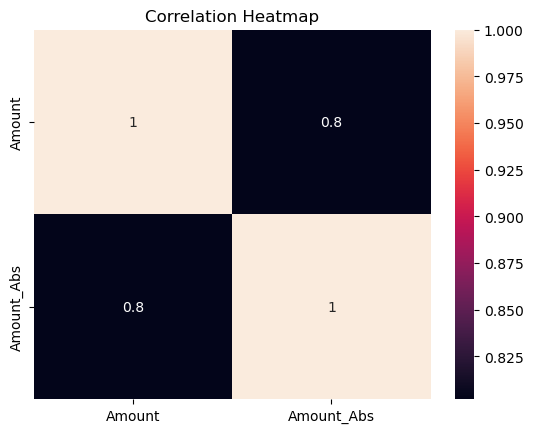

In [246]:
numeric_cols = [
    "Amount",
    "Amount_Abs"
]

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

In [247]:
print("Rows :", len(df))

print("Income Transactions :",
      len(df[df["Income_Expense"]=="Income"]))

print("Expense Transactions :",
      len(df[df["Income_Expense"]=="Expense"]))

print("Total Income :",
      df[df["Income_Expense"]=="Income"]["Amount_Abs"].sum())

print("Total Expense :",
      df[df["Income_Expense"]=="Expense"]["Amount_Abs"].sum())

Rows : 835
Income Transactions : 49
Expense Transactions : 786
Total Income : 378900
Total Expense : 342567
